# Sequences and Series

## Contents
1. [Basic Terms](#1.-Basic-Terms)
2. [Sigma (Σ) Notation](#2.-Sigma-(Σ)-Notation)
3. [Arithmetic Progression (AP)](#3.-Arithmetic-Progression-(AP))
4. [Sum of an AP](#4.-Sum-of-an-AP)
5. [Arithmetic Mean](#5.-Arithmetic-Mean)
6. [Geometric Progression (GP)](#6.-Geometric-Progression-(GP))
7. [Sum of a GP and Infinite GP](#7.-Sum-of-a-GP-and-Infinite-GP)
8. [Geometric Mean](#8.-Geometric-Mean)
9. [Harmonic Progression and Harmonic Mean](#9.-Harmonic-Progression-and-Harmonic-Mean)
10. [Relation Between AM, GM and HM](#10.-Relation-Between-AM,-GM-and-HM)
11. [Arithmetico-Geometric Progression (AGP)](#11.-Arithmetico-Geometric-Progression-(AGP))
12. [Sums of Special Series](#12.-Sums-of-Special-Series)
13. [Method of Differences and Telescoping Series](#13.-Method-of-Differences-and-Telescoping-Series)
14. [Recursive Sequences and Convergence](#14.-Recursive-Sequences-and-Convergence)
15. [Applications](#15.-Applications)
16. [Common Mistakes](#16.-Common-Mistakes)
17. [Formula Sheet](#17.-Formula-Sheet)
18. [Practice Problems (with Answers)](#18.-Practice-Problems-(with-Answers))

The code cells use **SymPy** for exact sums and NumPy/Matplotlib for graphs.

In [1]:
import math
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

n, k, x, a, d, r = sp.symbols("n k x a d r")

# Small helpers used throughout
def ap_term(a, d, n):  return a + (n - 1)*d
def ap_sum(a, d, n):   return sp.S(n) / 2 * (2*a + (n - 1)*d)
def gp_term(a, r, n):  return a * r**(n - 1)
def gp_sum(a, r, n):   return n*a if r == 1 else sp.S(a) * (sp.S(r)**n - 1) / (sp.S(r) - 1)
def gp_inf(a, r):      return a / (1 - r)          # valid only for |r| < 1

print("Helpers loaded.")

Helpers loaded.


## 1. Basic Terms

| Term | Meaning | Example |
|------|---------|---------|
| **Sequence** | An ordered list of numbers following a rule | $2, 5, 8, 11, \dots$ |
| **Term** | Each number in the list; $a_n$ (or $T_n$) is the $n$-th term | $a_3 = 8$ |
| **Finite sequence** | Has a last term | $1, 2, 3, \dots, 10$ |
| **Infinite sequence** | Goes on forever | $1, \tfrac{1}{2}, \tfrac{1}{4}, \dots$ |
| **Series** | The **sum** of the terms of a sequence | $2 + 5 + 8 + 11 + \dots$ |
| **Partial sum** $S_n$ | Sum of the first $n$ terms | $S_3 = 2 + 5 + 8 = 15$ |
| **Progression** | A sequence whose terms follow a definite pattern (AP, GP, HP) | |

### Two ways to describe a sequence
- **Explicit (general term) formula:** $a_n$ in terms of $n$. E.g. $a_n = 3n - 1$ gives $2, 5, 8, \dots$
- **Recursive formula:** each term from earlier ones. E.g. $a_1 = 2,\ a_{n} = a_{n-1} + 3$.

### Useful link between $S_n$ and $a_n$
$$a_1 = S_1, \qquad a_n = S_n - S_{n-1} \ \ (n \ge 2)$$

**Example.** $a_n = n^2 + 1$: the first four terms are $2, 5, 10, 17$.

## 2. Sigma (Σ) Notation

$$\sum_{k=1}^{n} a_k = a_1 + a_2 + \dots + a_n$$

$k$ is the **index** (a dummy variable — any letter works), $1$ is the lower limit, $n$ the upper limit. The number of terms is (upper − lower + 1).

**Example.** $\displaystyle\sum_{k=1}^{4} (2k + 1) = 3 + 5 + 7 + 9 = 24$.

### Properties
| Property | Rule |
|----------|------|
| Sum of a constant | $\displaystyle\sum_{k=1}^{n} c = nc$ |
| Constant factor | $\displaystyle\sum_{k=1}^{n} c\,a_k = c\sum_{k=1}^{n} a_k$ |
| Sum / difference | $\displaystyle\sum (a_k \pm b_k) = \sum a_k \pm \sum b_k$ |
| Splitting | $\displaystyle\sum_{k=1}^{n} a_k = \sum_{k=1}^{m} a_k + \sum_{k=m+1}^{n} a_k$ |

**Watch out:** $\sum a_k b_k \neq \left(\sum a_k\right)\left(\sum b_k\right)$ in general.

**Example.** $\displaystyle\sum_{k=1}^{20} (2k + 3) = 2\sum_{k=1}^{20} k + \sum_{k=1}^{20} 3 = 2(210) + 60 = 480$.

In [2]:
print(sp.summation(2*k + 1, (k, 1, 4)))
print(sp.summation(2*k + 3, (k, 1, 20)))

24
480


## 3. Arithmetic Progression (AP)

A sequence in which each term is obtained by **adding a fixed number** $d$ (the **common difference**) to the previous term:
$$a,\ a + d,\ a + 2d,\ a + 3d, \dots \qquad d = a_{n+1} - a_n$$

### General term
$$\boxed{a_n = a + (n - 1)d}$$

- $n$-th term **from the end** (last term $l$): $\;l - (n - 1)d$
- Number of terms from $a$ to $l$: $\;n = \dfrac{l - a}{d} + 1$
- $d > 0$: increasing; $d < 0$: decreasing; $d = 0$: constant.
- $a_n$ is a **linear** function of $n$ (graph of $(n, a_n)$ lies on a straight line with slope $d$).

**Example.** AP $3, 7, 11, \dots$: $a = 3,\ d = 4$, $\;a_{20} = 3 + 19 \cdot 4 = 79$.

**Example.** Which term of $21, 18, 15, \dots$ is $-81$? $\;21 + (n - 1)(-3) = -81 \Rightarrow n - 1 = 34 \Rightarrow n = 35$.

### Properties
- $a, b, c$ are in AP $\iff 2b = a + c$.
- Adding, subtracting, multiplying or dividing every term by a constant (non-zero for division) gives another AP.
- In a finite AP, terms equidistant from the beginning and end have the **same sum**: $a_k + a_{n-k+1} = a_1 + a_n$.
- $a_n = pn + q$ for constants $p, q$ $\iff$ the sequence is an AP (with $d = p$).

### Choosing terms cleverly
| Number of terms | Take | Common difference |
|-----------------|------|-------------------|
| 3 | $a - d,\ a,\ a + d$ | $d$ |
| 4 | $a - 3d,\ a - d,\ a + d,\ a + 3d$ | $2d$ |
| 5 | $a - 2d,\ a - d,\ a,\ a + d,\ a + 2d$ | $d$ |

**Example.** Three numbers in AP have sum 24 and product 440.
$3a = 24 \Rightarrow a = 8$; $\;(8 - d)(8)(8 + d) = 440 \Rightarrow 64 - d^2 = 55 \Rightarrow d = \pm 3$ → **5, 8, 11**.

## 4. Sum of an AP

$$\boxed{S_n = \frac{n}{2}\left[2a + (n - 1)d\right] = \frac{n}{2}(a + l)}$$
where $l = a_n$ is the last term.

**Proof (Gauss's trick).** Write the sum forwards and backwards:
$$S_n = a + (a + d) + \dots + l$$
$$S_n = l + (l - d) + \dots + a$$
Adding, each of the $n$ columns sums to $a + l$, so $2S_n = n(a + l)$. ∎

**Standard results**
- $1 + 2 + 3 + \dots + n = \dfrac{n(n + 1)}{2}$ (so $1 + 2 + \dots + 100 = 5050$)
- Sum of the first $n$ odd numbers: $1 + 3 + 5 + \dots + (2n - 1) = n^2$
- Sum of the first $n$ even numbers: $2 + 4 + \dots + 2n = n(n + 1)$

**Example.** $S_{20}$ of $3, 7, 11, \dots$ $= \frac{20}{2}(3 + 79) = 820$.

**Example.** Sum of all two-digit multiples of 3: $12, 15, \dots, 99$. $\;n = \frac{99 - 12}{3} + 1 = 30$, $\;S = \frac{30}{2}(12 + 99) = 1665$.

**Example (two answers).** How many terms of $24, 21, 18, \dots$ give a sum of 78?
$\frac{n}{2}[48 - 3(n - 1)] = 78 \Rightarrow 3n^2 - 51n + 156 = 0 \Rightarrow n^2 - 17n + 52 = 0 \Rightarrow n = 4$ or $13$.
**Both are valid**: the 9th term is 0 and terms 5 to 13 ($12, 9, \dots, -12$) cancel out.

**Example (from $S_n$ to $a_n$).** If $S_n = 3n^2 + 5n$, then $a_n = S_n - S_{n-1} = 6n + 2$. So it is an AP with $a = 8,\ d = 6$.

In [3]:
print("a_20 =", ap_term(3, 4, 20), "  S_20 =", ap_sum(3, 4, 20))
print("Which term is -81:", sp.solve(ap_term(21, -3, n) + 81, n))
print("Two-digit multiples of 3:", sum(range(12, 100, 3)))
print("n with S_n = 78:", sp.solve(ap_sum(24, -3, n) - 78, n), "  terms 5..13:", [ap_term(24, -3, i) for i in range(5, 14)])
S = 3*n**2 + 5*n
print("a_n from S_n:", sp.expand(S - S.subs(n, n - 1)))
print("Gauss:", sp.factor(sp.summation(k, (k, 1, n))), "| odd numbers:", sp.factor(sp.summation(2*k - 1, (k, 1, n))))

a_20 = 79   S_20 = 820
Which term is -81: [35]
Two-digit multiples of 3: 1665
n with S_n = 78: [4, 13]   terms 5..13: [12, 9, 6, 3, 0, -3, -6, -9, -12]
a_n from S_n: 6*n + 2
Gauss: n*(n + 1)/2 | odd numbers: n**2


## 5. Arithmetic Mean

The **arithmetic mean (AM)** of $a$ and $b$ is the number $A$ such that $a, A, b$ are in AP:
$$\boxed{A = \frac{a + b}{2}}$$

For $n$ numbers: $\;\text{AM} = \dfrac{a_1 + a_2 + \dots + a_n}{n}$.

### Inserting $n$ arithmetic means between $a$ and $b$
The resulting AP has $n + 2$ terms, so
$$d = \frac{b - a}{n + 1}, \qquad A_k = a + kd$$

**Fact:** the sum of the $n$ AMs inserted between $a$ and $b$ is $n \cdot \dfrac{a + b}{2}$.

**Example.** Insert 3 AMs between 3 and 19: $d = \frac{16}{4} = 4$ → $7, 11, 15$.

## 6. Geometric Progression (GP)

A sequence in which each term is obtained by **multiplying** the previous term by a fixed non-zero number $r$ (the **common ratio**):
$$a,\ ar,\ ar^2,\ ar^3, \dots \qquad r = \frac{a_{n+1}}{a_n}$$

### General term
$$\boxed{a_n = ar^{n-1}}$$

- $n$-th term from the end (last term $l$): $\;\dfrac{l}{r^{n-1}}$
- $r > 1$ (with $a > 0$): increasing; $0 < r < 1$: decreasing towards 0; $r < 0$: signs alternate.
- $a_n$ grows (or shrinks) **exponentially** in $n$.

**Example.** GP $2, 6, 18, \dots$: $a = 2,\ r = 3$, $\;a_8 = 2 \cdot 3^7 = 4374$.

**Example.** Which term of $2, 2\sqrt{2}, 4, \dots$ is 128? $\;r = \sqrt{2}$: $2(\sqrt{2})^{n-1} = 128 \Rightarrow (\sqrt{2})^{n-1} = 64 = (\sqrt{2})^{12} \Rightarrow n = 13$.

### Properties
- $a, b, c$ are in GP $\iff b^2 = ac$.
- Multiplying every term by a constant, taking reciprocals, or raising every term to the same power gives another GP.
- The product of terms equidistant from the beginning and end is constant: $a_k \cdot a_{n-k+1} = a_1 a_n$.
- If $a_1, a_2, \dots$ is a GP of positive terms, then $\log a_1, \log a_2, \dots$ is an **AP**.

### Choosing terms cleverly
| Number of terms | Take | Common ratio |
|-----------------|------|--------------|
| 3 | $\dfrac{a}{r},\ a,\ ar$ | $r$ |
| 4 | $\dfrac{a}{r^3},\ \dfrac{a}{r},\ ar,\ ar^3$ | $r^2$ |

**Example.** Three numbers in GP have product 216 and sum 19.
$a^3 = 216 \Rightarrow a = 6$; $\;\frac{6}{r} + 6 + 6r = 19 \Rightarrow 6r^2 - 13r + 6 = 0 \Rightarrow r = \tfrac{3}{2}$ or $\tfrac{2}{3}$ → **4, 6, 9**.

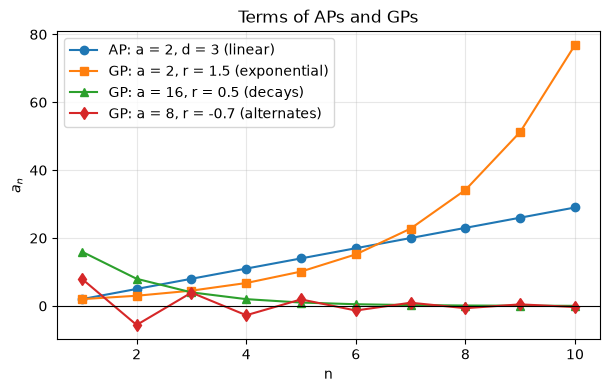

In [4]:
nn = np.arange(1, 11)
plt.figure(figsize=(7, 4))
plt.plot(nn, [ap_term(2, 3, i) for i in nn], "o-", label="AP: a = 2, d = 3 (linear)")
plt.plot(nn, [gp_term(2, 1.5, i) for i in nn], "s-", label="GP: a = 2, r = 1.5 (exponential)")
plt.plot(nn, [gp_term(16, 0.5, i) for i in nn], "^-", label="GP: a = 16, r = 0.5 (decays)")
plt.plot(nn, [gp_term(8, -0.7, i) for i in nn], "d-", label="GP: a = 8, r = -0.7 (alternates)")
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("n"); plt.ylabel("$a_n$"); plt.grid(alpha=0.3); plt.legend(); plt.title("Terms of APs and GPs")
plt.show()

## 7. Sum of a GP and Infinite GP

### Sum of the first $n$ terms
$$\boxed{S_n = \frac{a(r^n - 1)}{r - 1} = \frac{a(1 - r^n)}{1 - r}, \qquad r \neq 1}$$
(use the first form when $r > 1$, the second when $r < 1$). If $r = 1$, $S_n = na$.

**Proof.** $S_n = a + ar + \dots + ar^{n-1}$ and $rS_n = ar + ar^2 + \dots + ar^n$. Subtract: $S_n - rS_n = a - ar^n$. ∎

In terms of the last term $l$: $\;S_n = \dfrac{lr - a}{r - 1}$.

**Example.** $2 + 6 + 18 + \dots$ (8 terms) $= \dfrac{2(3^8 - 1)}{2} = 6560$.

### Infinite GP
If $|r| < 1$, then $r^n \to 0$ as $n \to \infty$, so
$$\boxed{S_\infty = \frac{a}{1 - r}, \qquad |r| < 1}$$
If $|r| \ge 1$ the series **diverges** (no finite sum).

**Example.** $1 + \frac{1}{2} + \frac{1}{4} + \dots = \dfrac{1}{1 - \frac{1}{2}} = 2$.

**Example.** $6 - 2 + \frac{2}{3} - \dots$: $a = 6,\ r = -\frac{1}{3}$, $\;S_\infty = \dfrac{6}{4/3} = 4.5$.

### Recurring decimals as fractions
- $0.\overline{3} = \frac{3}{10} + \frac{3}{100} + \dots = \dfrac{3/10}{1 - 1/10} = \dfrac{1}{3}$
- $0.\overline{36} = \dfrac{36/100}{1 - 1/100} = \dfrac{36}{99} = \dfrac{4}{11}$
- $0.1\overline{6} = \dfrac{1}{10} + \dfrac{6/100}{1 - 1/10} = \dfrac{1}{10} + \dfrac{1}{15} = \dfrac{1}{6}$

**Shortcut:** $0.\overline{abc} = \dfrac{abc}{999}$.

S_8 of 2, 6, 18, ... = 6560
1 + 1/2 + 1/4 + ... = 2
6 - 2 + 2/3 - ...   = 9/2
0.333... = 1/3 | 0.3636... = 4/11 | 0.1666... = 1/6


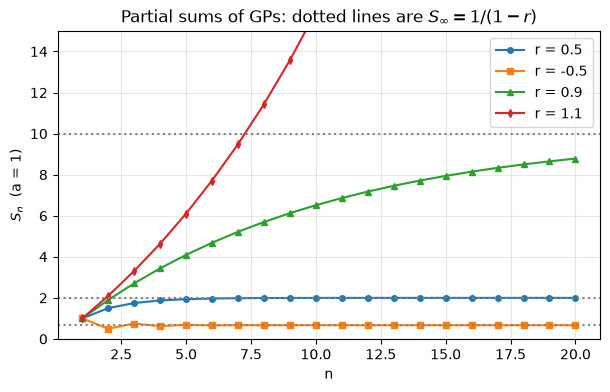

In [5]:
R = sp.Rational
print("S_8 of 2, 6, 18, ... =", gp_sum(2, 3, 8))
print("1 + 1/2 + 1/4 + ... =", gp_inf(1, R(1, 2)))
print("6 - 2 + 2/3 - ...   =", gp_inf(6, R(-1, 3)))
print("0.333... =", gp_inf(R(3, 10), R(1, 10)), "| 0.3636... =", gp_inf(R(36, 100), R(1, 100)),
      "| 0.1666... =", R(1, 10) + gp_inf(R(6, 100), R(1, 10)))

# Partial sums: converge when |r| < 1, diverge otherwise
N = np.arange(1, 21)
fig, ax = plt.subplots(figsize=(7, 4))
for rr, style in [(0.5, "o-"), (-0.5, "s-"), (0.9, "^-"), (1.1, "d-")]:
    ax.plot(N, [float(gp_sum(1, rr, int(i))) for i in N], style, ms=4, label=f"r = {rr}")
for rr in (0.5, -0.5, 0.9):
    ax.axhline(1 / (1 - rr), ls=":", color="gray")
ax.set_ylim(0, 15); ax.set_xlabel("n"); ax.set_ylabel("$S_n$  (a = 1)")
ax.set_title("Partial sums of GPs: dotted lines are $S_\\infty = 1/(1-r)$"); ax.grid(alpha=0.3); ax.legend()
plt.show()

## 8. Geometric Mean

The **geometric mean (GM)** of positive numbers $a$ and $b$ is $G$ such that $a, G, b$ are in GP:
$$\boxed{G = \sqrt{ab}}$$

For $n$ positive numbers: $\;\text{GM} = \sqrt[n]{a_1 a_2 \cdots a_n}$.

### Inserting $n$ geometric means between $a$ and $b$
$$r = \left(\frac{b}{a}\right)^{\frac{1}{n + 1}}, \qquad G_k = ar^k$$

**Fact:** the product of the $n$ GMs inserted between $a$ and $b$ is $\left(\sqrt{ab}\right)^n$.

**Example.** Insert 2 GMs between 3 and 81: $r^3 = 27 \Rightarrow r = 3$ → $9, 27$.

## 9. Harmonic Progression and Harmonic Mean

A sequence is a **harmonic progression (HP)** if the **reciprocals** of its terms form an AP.
$$\frac{1}{a}, \frac{1}{a + d}, \frac{1}{a + 2d}, \dots \qquad a_n = \frac{1}{a + (n - 1)d}$$

There is **no formula for the sum** of an HP. To solve HP problems, convert to the AP of reciprocals.

**Example.** $\frac{1}{2}, \frac{1}{5}, \frac{1}{8}, \dots$: reciprocals $2, 5, 8, \dots$ (AP, $d = 3$). The 10th reciprocal is $2 + 27 = 29$, so $a_{10} = \frac{1}{29}$.

### Harmonic mean
$H$ is the HM of $a$ and $b$ if $a, H, b$ are in HP:
$$\boxed{H = \frac{2ab}{a + b}}$$

For $n$ numbers: $\;\text{HM} = \dfrac{n}{\frac{1}{a_1} + \frac{1}{a_2} + \dots + \frac{1}{a_n}}$.

- $a, b, c$ in HP $\iff b = \dfrac{2ac}{a + c}$.
- **Average speed** for equal distances at speeds $u$ and $v$ is the HM $\dfrac{2uv}{u + v}$ (not the AM!). E.g. 40 km/h there and 60 km/h back → average speed 48 km/h.

## 10. Relation Between AM, GM and HM

For **positive** numbers $a, b$:
$$\boxed{A \ge G \ge H} \qquad \text{with equality} \iff a = b$$
$$\boxed{G^2 = AH} \qquad \text{(two numbers only)}$$

**Proof of AM ≥ GM.** $\;\dfrac{a + b}{2} - \sqrt{ab} = \dfrac{(\sqrt{a} - \sqrt{b})^2}{2} \ge 0$. ∎

The AM ≥ GM inequality also holds for $n$ positive numbers:
$$\frac{a_1 + a_2 + \dots + a_n}{n} \ge \sqrt[n]{a_1 a_2 \cdots a_n}$$

**Example.** For 4 and 16: $A = 10$, $G = 8$, $H = \frac{2 \cdot 64}{20} = 6.4$. Check: $A \ge G \ge H$ ✓ and $G^2 = 64 = 10 \times 6.4$ ✓.

### Using AM ≥ GM for maximum / minimum problems
- For $x > 0$: $\;x + \dfrac{1}{x} \ge 2\sqrt{x \cdot \tfrac{1}{x}} = 2$, minimum 2 at $x = 1$.
- For $x > 0$: $\;x + \dfrac{4}{x} \ge 2\sqrt{4} = 4$, minimum 4 at $x = 2$.
- If $a + b$ is fixed, $ab$ is **largest** when $a = b$. (A rectangle of fixed perimeter has maximum area when it is a square.)

### Finding $a, b$ from their means
$a$ and $b$ are the roots of $\;t^2 - 2At + G^2 = 0$.

In [6]:
def am(*v): return sum(v) / len(v)
def gm(*v): return math.prod(v) ** (1 / len(v))
def hm(*v): return len(v) / sum(1 / t for t in v)

for pair in [(4, 16), (9, 25), (5, 5), (1, 100)]:
    A, G, H = am(*pair), gm(*pair), hm(*pair)
    print(f"{pair}: AM = {A:.4f}  GM = {G:.4f}  HM = {H:.4f}   A>=G>=H: {A >= G - 1e-12 >= H - 2e-12}   G^2 - A*H = {G*G - A*H:.1e}")

print("\nAverage speed 40 & 60 km/h over equal distances:", round(hm(40, 60), 6))

(4, 16): AM = 10.0000  GM = 8.0000  HM = 6.4000   A>=G>=H: True   G^2 - A*H = 0.0e+00
(9, 25): AM = 17.0000  GM = 15.0000  HM = 13.2353   A>=G>=H: True   G^2 - A*H = 0.0e+00
(5, 5): AM = 5.0000  GM = 5.0000  HM = 5.0000   A>=G>=H: True   G^2 - A*H = 0.0e+00
(1, 100): AM = 50.5000  GM = 10.0000  HM = 1.9802   A>=G>=H: True   G^2 - A*H = 0.0e+00

Average speed 40 & 60 km/h over equal distances: 48.0


## 11. Arithmetico-Geometric Progression (AGP)

Each term is the product of an AP term and the corresponding GP term:
$$a,\ (a + d)r,\ (a + 2d)r^2,\ \dots, \qquad T_n = [a + (n - 1)d]\,r^{n-1}$$

### Finding the sum: multiply by $r$ and subtract
**Example.** $S = 1 + 2x + 3x^2 + 4x^3 + \dots$ (for $|x| < 1$)
$$xS = x + 2x^2 + 3x^3 + \dots$$
$$S - xS = 1 + x + x^2 + \dots = \frac{1}{1 - x} \quad\Rightarrow\quad S = \frac{1}{(1 - x)^2}$$

### Sum to infinity ($|r| < 1$)
$$\boxed{S_\infty = \frac{a}{1 - r} + \frac{dr}{(1 - r)^2}}$$

**Example.** $1 + \frac{2}{2} + \frac{3}{4} + \frac{4}{8} + \dots$: $a = 1,\ d = 1,\ r = \frac{1}{2}$ → $S_\infty = 2 + \dfrac{1/2}{1/4} = 4$.

In [7]:
res = sp.summation((k + 1) * x**k, (k, 0, sp.oo))     # SymPy returns a Piecewise: valid only for |x| < 1
expr, cond = sp.piecewise_fold(res).args[0]
print("1 + 2x + 3x^2 + ... =", sp.factor(expr), "  valid when", cond)
print("Σ n/2^(n-1)        =", sp.summation(k / 2**(k - 1), (k, 1, sp.oo)))

1 + 2x + 3x^2 + ... = (x - 1)**(-2)   valid when Abs(x) < 1
Σ n/2^(n-1)        = 4


## 12. Sums of Special Series

$$\sum_{k=1}^{n} k = \frac{n(n + 1)}{2}$$

$$\sum_{k=1}^{n} k^2 = \frac{n(n + 1)(2n + 1)}{6}$$

$$\sum_{k=1}^{n} k^3 = \left[\frac{n(n + 1)}{2}\right]^2 = \left(\sum_{k=1}^{n} k\right)^2$$

**Examples**
- $1^2 + 2^2 + \dots + 10^2 = \dfrac{10 \cdot 11 \cdot 21}{6} = 385$
- $1^3 + 2^3 + \dots + 10^3 = 55^2 = 3025$

### Series whose general term is a polynomial in $k$
Expand $T_k$, then apply the three formulas term by term.

**Example.** $1 \cdot 2 + 2 \cdot 3 + 3 \cdot 4 + \dots + n(n + 1)$:
$$\sum_{k=1}^{n} (k^2 + k) = \frac{n(n + 1)(2n + 1)}{6} + \frac{n(n + 1)}{2} = \frac{n(n + 1)(n + 2)}{3}$$
For $n = 10$: $\frac{10 \cdot 11 \cdot 12}{3} = 440$.

In [8]:
for expr in [k, k**2, k**3, k*(k + 1)]:
    print(f"Σ {str(expr):<10} = {sp.factor(sp.summation(expr, (k, 1, n)))}")
print("\nΣ k^2 (1..10) =", sum(i*i for i in range(1, 11)), "| Σ k^3 (1..10) =", sum(i**3 for i in range(1, 11)),
      "| Σ k(k+1) (1..10) =", sum(i*(i + 1) for i in range(1, 11)))

Σ k          = n*(n + 1)/2
Σ k**2       = n*(n + 1)*(2*n + 1)/6
Σ k**3       = n**2*(n + 1)**2/4
Σ k*(k + 1)  = n*(n + 1)*(n + 2)/3

Σ k^2 (1..10) = 385 | Σ k^3 (1..10) = 3025 | Σ k(k+1) (1..10) = 440


## 13. Method of Differences and Telescoping Series

### Method of differences
If the terms are not an AP or GP, look at the differences between consecutive terms. If **the differences form an AP**, the $n$-th term is a **quadratic** in $n$; if the differences form a GP, $T_n$ involves $r^n$.

**Example.** $1, 3, 7, 13, 21, \dots$ — differences $2, 4, 6, 8, \dots$ (AP).
Let $T_n = An^2 + Bn + C$ and use $T_1 = 1,\ T_2 = 3,\ T_3 = 7$ → $T_n = n^2 - n + 1$.
Then $\;S_n = \sum (k^2 - k + 1) = \dfrac{n(n + 1)(2n + 1)}{6} - \dfrac{n(n + 1)}{2} + n = \dfrac{n(n^2 + 2)}{3}$.

**Example.** $2, 5, 10, 17, 26, \dots$ — differences $3, 5, 7, 9$ → $T_n = n^2 + 1$.

### Telescoping series
Write $T_k = f(k) - f(k + 1)$ (often via **partial fractions**); then almost everything cancels:
$$\sum_{k=1}^{n} [f(k) - f(k + 1)] = f(1) - f(n + 1)$$

**Example.**
$$\sum_{k=1}^{n} \frac{1}{k(k + 1)} = \sum_{k=1}^{n} \left(\frac{1}{k} - \frac{1}{k + 1}\right) = 1 - \frac{1}{n + 1} = \frac{n}{n + 1}$$
As $n \to \infty$ the sum tends to $1$.

**Example.**
$$\sum_{k=1}^{n} \frac{1}{(2k - 1)(2k + 1)} = \frac{1}{2}\sum_{k=1}^{n}\left(\frac{1}{2k - 1} - \frac{1}{2k + 1}\right) = \frac{1}{2}\left(1 - \frac{1}{2n + 1}\right) = \frac{n}{2n + 1}$$

In [9]:
A_, B_, C_ = sp.symbols("A B C")
T = A_*n**2 + B_*n + C_
coeffs = sp.solve([T.subs(n, 1) - 1, T.subs(n, 2) - 3, T.subs(n, 3) - 7], [A_, B_, C_])
Tn = T.subs(coeffs)
print("T_n =", Tn, " -> first terms:", [Tn.subs(n, i) for i in range(1, 7)])
print("S_n =", sp.factor(sp.summation(Tn.subs(n, k), (k, 1, n))))
print("Σ 1/(k(k+1))       =", sp.simplify(sp.summation(1 / (k*(k + 1)), (k, 1, n))), " -> ∞:", sp.summation(1 / (k*(k + 1)), (k, 1, sp.oo)))
print("Σ 1/((2k-1)(2k+1)) =", sp.simplify(sp.summation(1 / ((2*k - 1)*(2*k + 1)), (k, 1, n))))
print("partial fractions  :", sp.apart(1 / (k*(k + 1)), k))

T_n = n**2 - n + 1  -> first terms: [1, 3, 7, 13, 21, 31]
S_n = n*(n**2 + 2)/3
Σ 1/(k(k+1))       = n/(n + 1)  -> ∞: 1
Σ 1/((2k-1)(2k+1)) = n/(2*n + 1)
partial fractions  : -1/(k + 1) + 1/k


## 14. Recursive Sequences and Convergence

### Recursive (recurrence) definitions
| Sequence | Recurrence | Terms |
|----------|-----------|-------|
| AP | $a_n = a_{n-1} + d$ | $a, a + d, \dots$ |
| GP | $a_n = r\,a_{n-1}$ | $a, ar, \dots$ |
| Factorial | $n! = n \cdot (n - 1)!$, $0! = 1$ | $1, 1, 2, 6, 24, \dots$ |
| **Fibonacci** | $F_n = F_{n-1} + F_{n-2}$, $F_1 = F_2 = 1$ | $1, 1, 2, 3, 5, 8, 13, \dots$ |

The ratio of consecutive Fibonacci numbers approaches the **golden ratio**
$$\varphi = \frac{1 + \sqrt{5}}{2} \approx 1.618$$

### Convergence (introduction)
- A **sequence** converges if its terms approach a single number (its **limit**). $\tfrac{1}{n} \to 0$; $(-1)^n$ does not converge.
- A **series** converges if its partial sums $S_n$ approach a finite number.
- If $\sum a_n$ converges, then $a_n \to 0$. **The converse is false**:
  the **harmonic series** $1 + \frac{1}{2} + \frac{1}{3} + \dots$ has terms $\to 0$ but **diverges** (grows like $\ln n$).
- $\sum \frac{1}{n^2} = 1 + \frac{1}{4} + \frac{1}{9} + \dots$ converges, to $\frac{\pi^2}{6} \approx 1.645$.
- A GP converges $\iff |r| < 1$.

Fibonacci: [1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610]


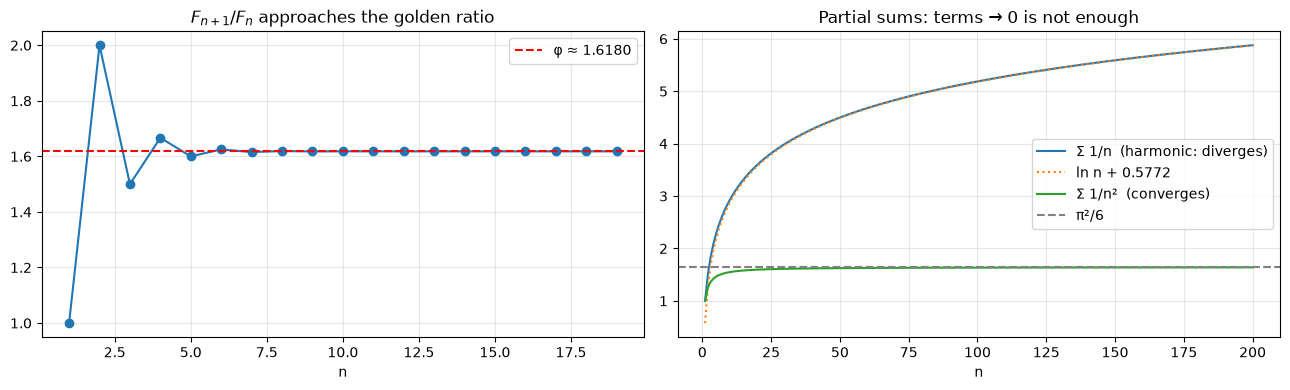

In [10]:
fib = [1, 1]
for _ in range(18):
    fib.append(fib[-1] + fib[-2])
print("Fibonacci:", fib[:15])
phi = (1 + 5**0.5) / 2
ratios = [fib[i + 1] / fib[i] for i in range(len(fib) - 1)]

N = np.arange(1, 201)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(1, len(ratios) + 1), ratios, "o-")
axes[0].axhline(phi, color="red", ls="--", label=f"φ ≈ {phi:.4f}")
axes[0].set_title("$F_{n+1} / F_n$ approaches the golden ratio"); axes[0].set_xlabel("n"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(N, np.cumsum(1 / N), label="Σ 1/n  (harmonic: diverges)")
axes[1].plot(N, np.log(N) + 0.5772, ":", label="ln n + 0.5772")
axes[1].plot(N, np.cumsum(1 / N**2), label="Σ 1/n²  (converges)")
axes[1].axhline(math.pi**2 / 6, color="gray", ls="--", label="π²/6")
axes[1].set_title("Partial sums: terms → 0 is not enough"); axes[1].set_xlabel("n"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 15. Applications

| Situation | Model |
|-----------|-------|
| **Simple interest** (principal $P$, rate $R\%$ p.a.) | Amounts form an **AP**: $A_n = P\left(1 + \frac{nR}{100}\right)$ |
| **Compound interest** | Amounts form a **GP**: $A_n = P\left(1 + \frac{R}{100}\right)^n$ |
| **Population growth** at $R\%$ per year | GP with $r = 1 + \frac{R}{100}$ |
| **Depreciation** at $R\%$ per year | GP with $r = 1 - \frac{R}{100}$ |
| Savings that increase by a fixed amount each month | AP; total saved = $S_n$ |
| Bouncing ball, repeated halving | Infinite GP |

**Example (interest).** ₹10,000 for 3 years at 10% p.a.
- Simple interest: $10000, 11000, 12000, 13000$ (AP, $d = 1000$) → ₹13,000.
- Compound interest: $10000 \cdot 1.1^3 = $ ₹13,310 (GP, $r = 1.1$).

**Example (population).** A town of 50,000 grows 4% per year. After 2 years: $50000 \cdot 1.04^2 = 54{,}080$.

**Example (savings).** Saving ₹100 in month 1 and ₹20 more each month: total after 12 months $= \frac{12}{2}[200 + 11 \cdot 20] = $ ₹2,520.

**Example (bouncing ball).** A ball dropped from 10 m rebounds to $\tfrac{3}{4}$ of its height each time. Total distance travelled:
$$10 + 2\left(10 \cdot \tfrac{3}{4} + 10 \cdot \left(\tfrac{3}{4}\right)^2 + \dots\right) = 10 + 2 \cdot \frac{7.5}{1 - 3/4} = 10 + 60 = 70 \text{ m}$$

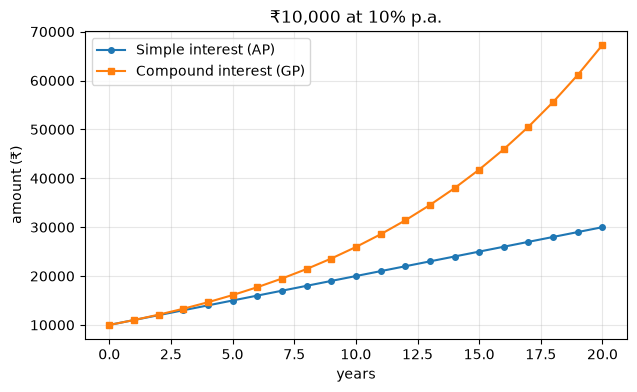

After 3 years: simple = 13000.0  compound = 13310.0
Population: 54080
Savings: 2520
Ball: 70


In [11]:
years = np.arange(0, 21)
P, rate = 10000, 0.10
plt.figure(figsize=(7, 4))
plt.plot(years, P * (1 + rate * years), "o-", ms=4, label="Simple interest (AP)")
plt.plot(years, P * (1 + rate) ** years, "s-", ms=4, label="Compound interest (GP)")
plt.xlabel("years"); plt.ylabel("amount (₹)"); plt.title("₹10,000 at 10% p.a."); plt.grid(alpha=0.3); plt.legend()
plt.show()

print("After 3 years: simple =", P * (1 + rate * 3), " compound =", round(P * (1 + rate) ** 3, 2))
print("Population:", round(50000 * 1.04**2))
print("Savings:", ap_sum(100, 20, 12))
print("Ball:", 10 + 2 * gp_inf(sp.Rational(15, 2), sp.Rational(3, 4)))

## 16. Common Mistakes

| Mistake | Correct |
|---------|---------|
| $a_n = a + nd$ | $a_n = a + (n - 1)d$ |
| $a_n = ar^n$ | $a_n = ar^{n-1}$ |
| Computing $d$ as $a_1 - a_2$ | $d = a_2 - a_1$ (later minus earlier) |
| Off-by-one when counting terms from $a$ to $l$ | $n = \frac{l - a}{d} + 1$ |
| Using $S_\infty = \frac{a}{1 - r}$ when $\lvert r\rvert \ge 1$ | The series diverges — no sum |
| Rejecting a valid second value of $n$ in "how many terms" problems | Check both; negative terms can cancel |
| Assuming $a_n = S_n$ | $a_n = S_n - S_{n-1}$ |
| Average speed $= \frac{u + v}{2}$ for equal distances | It is the HM $\frac{2uv}{u + v}$ |
| Looking for a sum formula for an HP | Work with the AP of reciprocals |
| "Terms → 0, so the series converges" | False — the harmonic series diverges |
| $\sum a_k b_k = \sum a_k \cdot \sum b_k$ | Not true in general |
| Applying AM ≥ GM to negative numbers | Only valid for non-negative numbers |

## 17. Formula Sheet

| Item | Formula |
|------|---------|
| AP general term | $a_n = a + (n - 1)d$ |
| AP sum | $S_n = \dfrac{n}{2}[2a + (n - 1)d] = \dfrac{n}{2}(a + l)$ |
| Number of terms | $n = \dfrac{l - a}{d} + 1$ |
| Term from sum | $a_n = S_n - S_{n-1}$ |
| AM | $\dfrac{a + b}{2}$; $n$ AMs: $d = \dfrac{b - a}{n + 1}$ |
| GP general term | $a_n = ar^{n-1}$ |
| GP sum | $S_n = \dfrac{a(r^n - 1)}{r - 1}$, $r \neq 1$ |
| Infinite GP | $S_\infty = \dfrac{a}{1 - r}$, $\lvert r\rvert < 1$ |
| GM | $\sqrt{ab}$; $n$ GMs: $r = (b/a)^{1/(n+1)}$ |
| HP | reciprocals in AP; $a_n = \dfrac{1}{a + (n - 1)d}$ |
| HM | $\dfrac{2ab}{a + b}$ |
| Means | $A \ge G \ge H$; $\;G^2 = AH$ |
| Three in AP / GP / HP | $2b = a + c$ / $b^2 = ac$ / $b = \dfrac{2ac}{a + c}$ |
| AGP to infinity | $\dfrac{a}{1 - r} + \dfrac{dr}{(1 - r)^2}$ |
| $\sum k$ | $\dfrac{n(n + 1)}{2}$ |
| $\sum k^2$ | $\dfrac{n(n + 1)(2n + 1)}{6}$ |
| $\sum k^3$ | $\left[\dfrac{n(n + 1)}{2}\right]^2$ |
| Telescoping | $\sum_{k=1}^{n} [f(k) - f(k + 1)] = f(1) - f(n + 1)$ |
| $\sum \frac{1}{k(k + 1)}$ | $\dfrac{n}{n + 1}$ |
| Compound interest | $A = P\left(1 + \frac{R}{100}\right)^n$ |

## 18. Practice Problems (with Answers)

### Level 1 — Basics
1. Find the 15th term of the AP $7, 12, 17, \dots$
2. Find the sum of the first 25 terms of $2, 5, 8, \dots$
3. Which term of $3, 8, 13, \dots$ is 248?
4. Find the 10th term of the GP $5, 10, 20, \dots$
5. Find the sum to infinity of $6 - 2 + \frac{2}{3} - \dots$
6. Find the AM, GM and HM of 9 and 25.
7. Evaluate $\displaystyle\sum_{k=1}^{20} (2k + 3)$.

### Level 2 — Standard
8. Find the sum of all natural numbers between 100 and 200 that are divisible by 7.
9. If $S_n = 2n^2 + 3n$, find $a_n$.
10. Three numbers in AP have sum 15 and product 80. Find them.
11. Insert 4 arithmetic means between 3 and 23.
12. Write $0.\overline{27}$ as a fraction.
13. The 3rd term of a GP is 12 and the 6th term is 96. Find the GP.
14. How many terms of $3, 6, 12, \dots$ add up to 381?

### Level 3 — Challenge
15. Find $1 \cdot 2 + 2 \cdot 3 + \dots + 10 \cdot 11$.
16. Find $\dfrac{1}{1 \cdot 2} + \dfrac{1}{2 \cdot 3} + \dots + \dfrac{1}{99 \cdot 100}$.
17. Find $1 + \dfrac{3}{3} + \dfrac{5}{9} + \dfrac{7}{27} + \dots$ to infinity.
18. A ball is dropped from 16 m and rebounds to half its height each time. Find the total distance travelled.
19. Find the $n$-th term and the sum of $n$ terms of $2, 5, 10, 17, 26, \dots$
20. Find the minimum value of $x + \dfrac{4}{x}$ for $x > 0$.

<details>
<summary><strong>Answers</strong> (click to expand)</summary>

1. $7 + 14 \cdot 5 = 77$
2. $\frac{25}{2}(4 + 72) = 950$
3. $3 + 5(n - 1) = 248 \Rightarrow n = 50$
4. $5 \cdot 2^9 = 2560$
5. $\dfrac{6}{1 + 1/3} = 4.5$
6. AM $= 17$, GM $= 15$, HM $= \frac{225}{17} \approx 13.24$
7. $480$
8. $105, 112, \dots, 196$: 14 terms, sum $= 7(105 + 196) = 2107$
9. $a_n = 4n + 1$
10. $2, 5, 8$
11. $7, 11, 15, 19$
12. $\frac{27}{99} = \frac{3}{11}$
13. $r^3 = 8 \Rightarrow r = 2,\ a = 3$: $3, 6, 12, 24, \dots$
14. $3(2^n - 1) = 381 \Rightarrow 2^n = 128 \Rightarrow n = 7$
15. $\frac{10 \cdot 11 \cdot 12}{3} = 440$
16. $1 - \frac{1}{100} = \frac{99}{100}$
17. AGP with $a = 1, d = 2, r = \frac{1}{3}$: $\frac{3}{2} + \frac{2/3}{4/9} = 3$
18. $16 + 2 \cdot \frac{8}{1 - 1/2} = 48$ m
19. $T_n = n^2 + 1$; $\;S_n = \frac{n(n + 1)(2n + 1)}{6} + n$
20. AM ≥ GM: $x + \frac{4}{x} \ge 2\sqrt{4} = 4$, minimum 4 at $x = 2$

</details>

In [12]:
# Check the practice answers
R = sp.Rational
print(" 1.", ap_term(7, 5, 15))
print(" 2.", ap_sum(2, 3, 25))
print(" 3.", sp.solve(ap_term(3, 5, n) - 248, n))
print(" 4.", gp_term(5, 2, 10))
print(" 5.", gp_inf(6, R(-1, 3)))
print(" 6.", R(9 + 25, 2), sp.sqrt(9*25), R(2*9*25, 9 + 25))
print(" 7.", sp.summation(2*k + 3, (k, 1, 20)))
print(" 8.", sum(i for i in range(101, 200) if i % 7 == 0))
S = 2*n**2 + 3*n; print(" 9.", sp.expand(S - S.subs(n, n - 1)), "(a_1 =", S.subs(n, 1), ")")
dd = sp.symbols("dd"); print("10.", [[5 - s, 5, 5 + s] for s in sp.solve((5 - dd)*5*(5 + dd) - 80, dd) if s > 0])
print("11.", [3 + i*R(23 - 3, 5) for i in range(1, 5)])
print("12.", gp_inf(R(27, 100), R(1, 100)))
rr = [s for s in sp.solve(r**3 - 8, r) if s.is_real][0]; print("13.", [gp_term(12 / rr**2, rr, i) for i in range(1, 6)])
print("14.", sp.solve(gp_sum(3, 2, n) - 381, n))
print("15.", sp.summation(k*(k + 1), (k, 1, 10)))
print("16.", sp.summation(1 / (k*(k + 1)), (k, 1, 99)))
print("17.", sp.summation((2*k + 1) / 3**k, (k, 0, sp.oo)))
print("18.", 16 + 2 * gp_inf(8, R(1, 2)))
print("19.", [i**2 + 1 for i in range(1, 6)], "| S_n =", sp.factor(sp.summation(k**2 + 1, (k, 1, n))))
xp = sp.symbols("xp", positive=True); f = xp + 4/xp
crit = sp.solve(sp.diff(f, xp), xp); print("20.", "min", f.subs(xp, crit[0]), "at x =", crit[0])

 1. 77
 2. 950
 3. [50]
 4. 2560
 5. 9/2
 6. 17 15 225/17
 7. 480
 8. 2107
 9. 4*n + 1 (a_1 = 5 )
10. [[2, 5, 8]]
11. [7, 11, 15, 19]
12. 3/11
13. [3, 6, 12, 24, 48]
14. [7]
15. 440
16. 99/100
17. 3
18. 48
19. [2, 5, 10, 17, 26] | S_n = n*(2*n**2 + 3*n + 7)/6


20.

 min 4 at x = 2
